<sub>Felix Becker, Lars Gabriel University of Greifswald, Germany</sub>
# Solutions to Exercise Set 2 - 1: A simple neural network for bike rentals

We will now create a simple neural network that predicts rental counts based on different attributes as defined in the first exercise (matrix $X$).

We will also learn how to optimize relevant hyperparameters of the model without underestimating the true test error.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

2025-03-08 17:36:48.415087: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-08 17:36:48.415287: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-08 17:36:48.417724: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-08 17:36:48.449465: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-08 17:36:48.986268: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

## Task 1: Preparations

Shuffle with `np.random.shuffle` and split X and y into ``X_train``, ``X_test``, ``y_train`` and ``y_test``.

In [2]:
np.random.seed(0) # so we all get the same pseudorandom results, do not modify or remove this line!

# load X and y
X = np.load("../../X.npy")
y = np.load("../../y.npy")

m,n = X.shape

# split into train and test
test_split = 0.1



# shuffle X and y (attention, shuffle them together, i.e. keep the one-one correspondance of rows of X and values in y)
# split X and y by keeping the first (test_split*100)% examples for testing. Use the rest for training.
# Name the splitted values X_train, X_test, y_train and y_test.
perm = np.arange(m)
np.random.shuffle(perm) # shuffle all data examples, why is this important?

# YOUR CODE STARTS
k = int(m*test_split)
X_test = X[perm[:k]] # 0..k-1
X_train = X[perm[k:]] # k..end
y_test = y[perm[:k]]
y_train = y[perm[k:]]

# YOUR CODE ENDS

## Task 2: Model search

0. Run all cells until Task 3 as they are now, i.e. without adding your own code yet. This trains a linear regression (i.e. a neural network without hidden layers) as a baseline model.
1. Then return to the cell below and create a small neural network with hidden layers of various sizes and an activation function of your choice.
2. Add a L2 regularizer with ``kernel_regularizer=tf.keras.regularizers.L2(l2)`` to each Dense layer you create.
3. After training, take note of *validation* error, come back here, change some hyperparameters and train again. Also adapt the l2 loss strength maintaining a value > 0. Iterate as much as you like, but do not base decisions on the *test* error (ignore it, for now). 
4. Report (as a group) the final *test* error of the best model and its configuration. Who wins? What is the improvement with respect to the baseline model (linear regression)?

In [3]:
tf.random.set_seed(0) # so we all get the same pseudorandom results, do not modify or remove

l2 = 0.01 #strength of l2 regularization for all kernels

def make_model():
    # a neural network is a stack of layers, in keras called "Sequential" model
    model = tf.keras.models.Sequential() # so far the stack is empty, 0 layers

    #YOUR CODE STARTS
    # add Dense neural network layers with number of hidden neurons, activation function of your choice.
    # add a L2 regularizer for each layer
    for i in range(4):
        model.add(tf.keras.layers.Dense(32,
                                        activation = tf.nn.relu,
                                        kernel_regularizer = tf.keras.regularizers.L2(l2)))
    #YOUR CODE ENDS
    
    #last layer maps to output size 1 and has no activation function
    model.add(tf.keras.layers.Dense(1, kernel_regularizer = tf.keras.regularizers.L2(l2)))
    
    return model

model = make_model()


In addition to our loss (MSE) we use the **Root Mean Squared Error** as a metric.

$RMSE(\theta) = \sqrt(MSE(\theta))$

It can be interpreted as an average distance of our prediction to the true value.

A **metric** is (in constrast to a **loss**) not used for model optimization but for evaluation.

In [4]:
def fit_model(model, X_train, y_train, epochs=200, learning_rate = 0.01):
    # define the loss, optimization algorithm and prepare the model for gradient computation 
    opti = tf.keras.optimizers.Adam(learning_rate = learning_rate) # Adam is a popular method for stochastic gradient descent
    model.compile(optimizer = opti, loss = "mse", metrics = [tf.keras.metrics.RootMeanSquaredError()]) 
    # execute the actual training 
    val_split = 0.15
    history = model.fit(X_train, y_train, epochs = epochs, batch_size=64, validation_split=val_split, verbose = 0) 
    return history

In [5]:
# takes ~1min
# a larger batch size can speed this up, however it can negatively affect the outcome
# since fewer training steps are made
# the same is true for smaller numbers of epochs
history = fit_model(model, X_train, y_train)
model.summary()

2025-03-08 17:36:49.545056: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-08 17:36:49.545293: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,893 (38.65 KB)

 Trainable params: 3,297 (12.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,596 (25.77 KB)

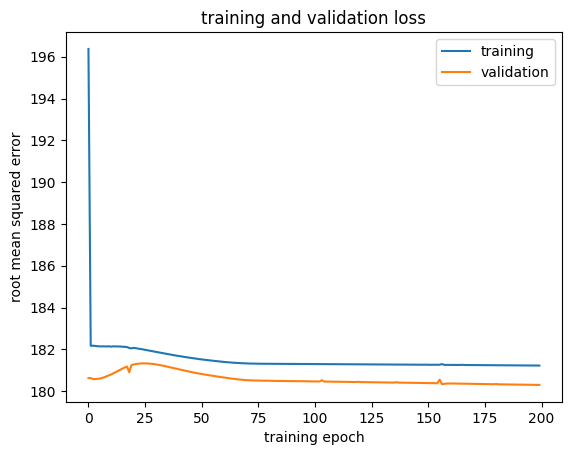

In [6]:
fig, ax= plt.subplots(1,1)
def plot_hist(history, ax, title, ylim=None):
    ax.plot(history.history["root_mean_squared_error"], label="training") 
    ax.plot(history.history["val_root_mean_squared_error"], label="validation") 
    ax.set_title(title)
    ax.set_xlabel("training epoch")
    ax.set_ylabel("root mean squared error")
    handles, labels = ax.get_legend_handles_labels()
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.legend(handles, labels)
plot_hist(history, ax, "training and validation loss")

In [7]:
# for simplicity we take the last validation loss only
print("val mse=", history.history["val_root_mean_squared_error"][-1])

val mse= 180.29566955566406


In [8]:
# compute test error
l = model.evaluate(X_test, y_test)
print("test mse, rmse=", l)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step - loss: 31087.7402 - root_mean_squared_error: 176.1761
test mse, rmse= [33446.96875, 182.8836669921875]


In [9]:
print("predictions =\t", model.predict(X_test).flatten().astype(np.int32))
print("truth =\t\t", y_test)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step
predictions =	 [196 196 196 ... 196 196 196]
truth =		 [244 239 229 ... 103   1  39]


Iterate at least until you have a lower validation RMSE than with the linear regression baseline.

## Task 3: Transfer learning and Fine-Tuning

We now have a well working neural network architecture and a trained ``model`` at hand. Naturally, as a black box, we can hardly tell anything about the inner workings of the neural network, i.e. we see that a prediction is good, but can't tell why.

However, we expect the inner layers of the neural network to learn *something* about the semantics of the problem space at hand.

To see this, assume we now have a different training target that is related to the original one. The dataset contains a "registered" column that counts only those rentals, with a registration (club membership). "registered" is similar to count, but not the same because it misses casual rentals. Maybe we can expect casual rentals to be higher in summer and spring and expect registered members to use the service more regularily over the year. In machine learning terms predicting 'registered' is a different but related *task*.

*Question: Can we use the hidden features of the already trained model for "count" to train a model for "registered"?*

To answer this, you will train two models in the following: 
1. ``model1`` is identical to the original model except the last layer (Dense(1))
2. ``model2`` is completely new

To achieve this, use the trained ``model`` from previous cells and access its layer list with ``model.layers``. Reuse these layers for the new model (``.add``) and remember to leave out the last layer. Replace it with a new one and also apply L2 regularization to it.

Use ``fit_model`` to train both models on ``y_registered_train`` and try fewer epochs (e.g. 100) for model1 as it already has trained hidden features. This is called *fine-tuning* as we are using already trained parameters (as opposed to randomly initialized ones in `model2`) and continue their training, albeit for another task.

Name the two return values of ``fit_model`` depending on whether fine-tuning used or not `history1` and `history2`, respectively.

How does the loss curve change?

In [10]:
y_registered = pd.read_csv("../../bikes-summerdays-full.csv", sep = ";")["registered"]
k = int(m*test_split)
y_registered_train = y_registered[perm[k:]]
y_registered_test = y_registered[perm[:k]]

In [11]:
#YOUR CODE STARTS
#construct model1 and model2 as described above, train them and name the results history1 and history2
model1 = tf.keras.models.Sequential()
for layer in model.layers[:-1]: 
    model1.add(layer)
# model1.add(tf.keras.layers.Dense(8, activation = tf.nn.relu)) #you could also add a new hidden layer on top of the previous model
model1.add(tf.keras.layers.Dense(1))

model2 = make_model()

In [12]:
history1 = fit_model(model1, X_train, y_registered_train, epochs=20) #fewer epochs!
history2 = fit_model(model2, X_train, y_registered_train, epochs=20)
#YOUR CODE ENDS

In [13]:
# take note that all models have the same architecture and number of parameters
for name, mdl in zip(["model", "model1, transfer learning", "model2"], [model, model1, model2]):
    print (name)
    mdl.summary()

model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,893 (38.65 KB)

 Trainable params: 3,297 (12.88 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,893 (38.65 KB)

 Trainable params: 3,297 (12.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,596 (25.77 KB)

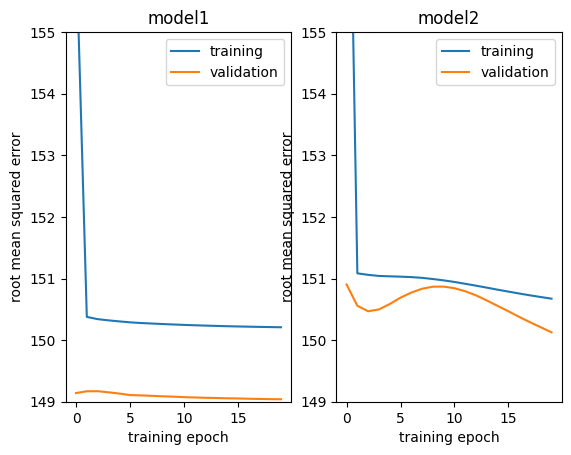

In [14]:
fig, axes = plt.subplots(1,2)
plot_hist(history1, axes[0], "model1", ylim=(149,155))
plot_hist(history2, axes[1], "model2", ylim=(149,155))

In [15]:
print("test mse 1=", model1.evaluate(X_test, y_registered_test, verbose=0))
print("test mse 2=", model2.evaluate(X_test, y_registered_test, verbose=0))

test mse 1= [23047.50390625, 151.8120574951172]
test mse 2= [23264.30859375, 152.5243682861328]


$\implies$ model 1 should achieve similar test errors but training converges much faster

If `model1` performs worse than `model2`, try to transfer fewer layers. If your model architecture is more deep than broad, this might help.
Try to make the cut at a layer with many neurons. If your last hidden layer before the output layer has only 2 neurons, this might be a bottleneck that is too much tuned to the first task and not suitable for transfer learning. Also try to leave out the L2 regularizer on the new layer of `model1` as we do not need to regularize on an already pre-trained model as much.

### Improve the model search 

From here, if you want to practice off-course more or want to apply neural networks to your own data, you should consider averaging the test error over many different training-validation-test splits of the data. This is called **cross-validation** and it will trade experiment time for decreased randomness in the reported result. 